# Sélection de paramètres de régularisation après sélection et estimations des paramètres

Le but de ce notebook est de tester une nouvelle méthode pour sélectionner depuis une grille de valeur le paramètre de regularisation dans un contexte de selection de support avec la pénalisation LASSO.

Après une rapide description du modèle, on affiches différents graphes montrant des chemins de regularization provenant d'UNE simulation !

In [13]:
import sdg4varselect.plot as sdgplt
import jax.numpy as jnp
import jax.random as jrd

sdgplt.FIGSIZE = 10

## Dataset generation

First, let's generate a data set corresponding to a joint model of longitduinal logistic data and a Cox model.


$$ \left\{\begin{array}{rll}
            h(t|U_i) 
            &=h_{0}(t) \exp(\beta^T U_i + \alpha m(t,\varphi_i))
            \\ Y_{i,j} &= m(t_j; \varphi_i) + \varepsilon_{i,j}
            \\ \varphi_i \sim \mathcal N(\mu, \Gamma)   
            & ; ~\varepsilon_{i,j} \sim \mathcal N(0,\sigma^2).             
        \end{array}\right. ~ \forall i \in\{1,...,N\}, j\in\{1,...,J\}$$

where : $m(t_j; \varphi_i) = \frac{\varphi_{1,i}}{1+\exp\left(\frac{\varphi_{2,i}-t_j}{\varphi_{3,i}} \right)}$ and $h_{0}(t)= b a^{-b} t^{b-1}$ with $a=80$ and $b=35$

In [9]:
from sdg4varselect.logistic import Logistic_JM

model = Logistic_JM(N=100, J=5, DIM_HD=200)

## Simulation Results
All calculations have been performed on the cluster, so we load the results files for $N=100$ and two scenarios $P\in\{100,200\}$


In [10]:
import gzip
import pickle


R = pickle.load(gzip.open(f"new_reg_path_100.pkl.gz", "rb"))
lbd_set, reg_path_HD_100 = R["lbd_set"], R["reg_path"]

R = pickle.load(gzip.open(f"new_reg_path_200.pkl.gz", "rb"))
reg_path_HD_200 = R["reg_path"]

We wish to observe the difference between the BIC criterion calculated from the estimation of the high-dimensional parameter support (called "selection") and the BIC criterion calculated after parameter estimates from the model reduced to the selected support (called "estimation"). More concretely, we compare the BIC calculated with $\hat \theta_{LASSO}$ or with $\hat \theta_{MLE}$ :

$$\hat \theta_{LASSO}(\lambda)= argmax_{\theta\in\Theta} \left\{ \log  \mathcal L_{marg}(\theta ; \mathcal D) - \lambda  \ pen_{Lasso}(\theta) \right\},$$
or 

$$\hat \theta_{MLE}(\lambda)= argmax_{\theta\in\Theta_{shrink; \lambda}} \left\{ \log  \mathcal L_{marg}(\theta ; \mathcal D_{shrink}) \right\},$$

where $\mathcal \Theta_{shrink;\lambda}$ is the parameter space shrink to the selected variables with $\lambda$ as regularization parameter.




We can now calculate the BIC criterion after variable selection and after estimation :

$$BIC (\lambda) = - 2 \log(\mathcal L_{marg}(\hat\theta(\lambda); \mathcal D)) + k \ \log(N\times(J+1))$$ 

where $k = \#\{\beta_i != 0 \}$

In [11]:
from sdg4varselect.algo import BIC

bic_selection_100 = BIC(
    jnp.array([res[0].theta[-1, 7:] for res in reg_path_HD_100]),
    jnp.array([res[0].likelihood for res in reg_path_HD_100]),
    model.N * (model.J + 1),
)
bic_estimation_100 = BIC(
    jnp.array([res[1].theta[-1, 7:] for res in reg_path_HD_100]),
    jnp.array([res[1].likelihood for res in reg_path_HD_100]),
    model.N * (model.J + 1),
)

bic_selection_200 = BIC(
    jnp.array([res[0].theta[-1, 7:] for res in reg_path_HD_200]),
    jnp.array([res[0].likelihood for res in reg_path_HD_200]),
    model.N * (model.J + 1),
)
bic_estimation_200 = BIC(
    jnp.array([res[1].theta[-1, 7:] for res in reg_path_HD_200]),
    jnp.array([res[1].likelihood for res in reg_path_HD_200]),
    model.N * (model.J + 1),
)

Below is a plot of the regularization path for BIC selection (i.e. before estimation).

Text(0.5, 1.0, 'Regularization path N=100, J = 5, P = 200, after estimation')

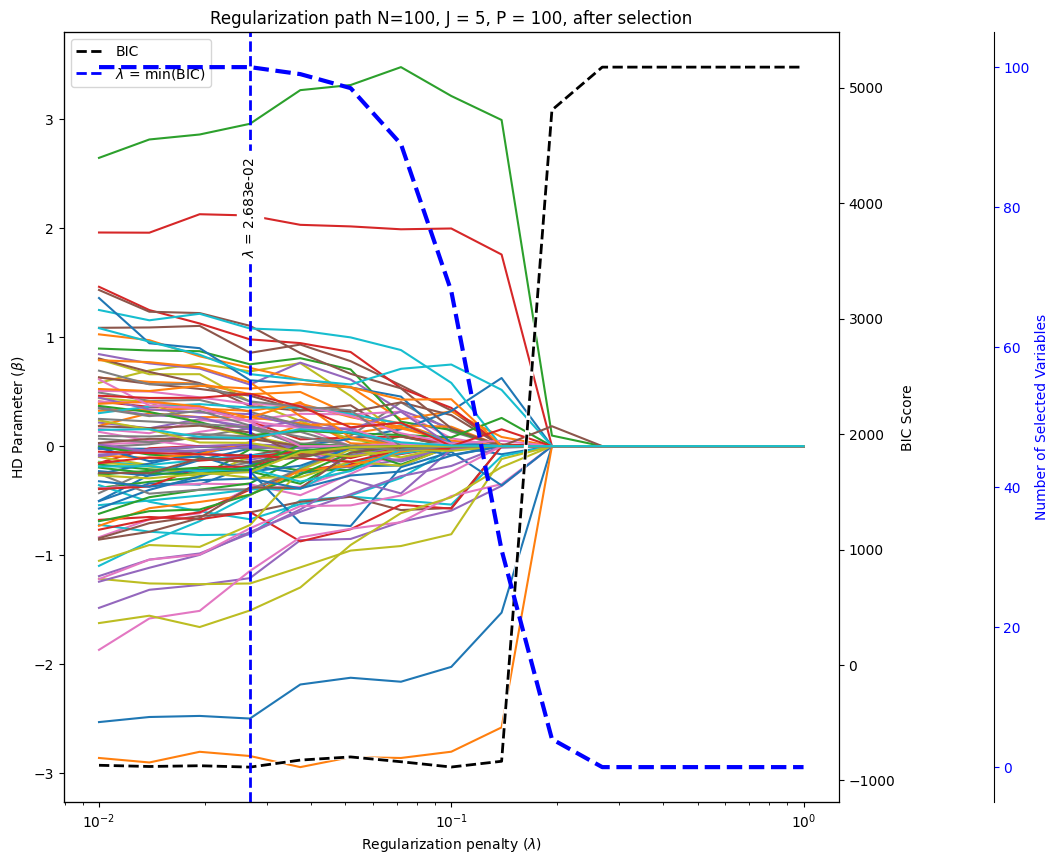

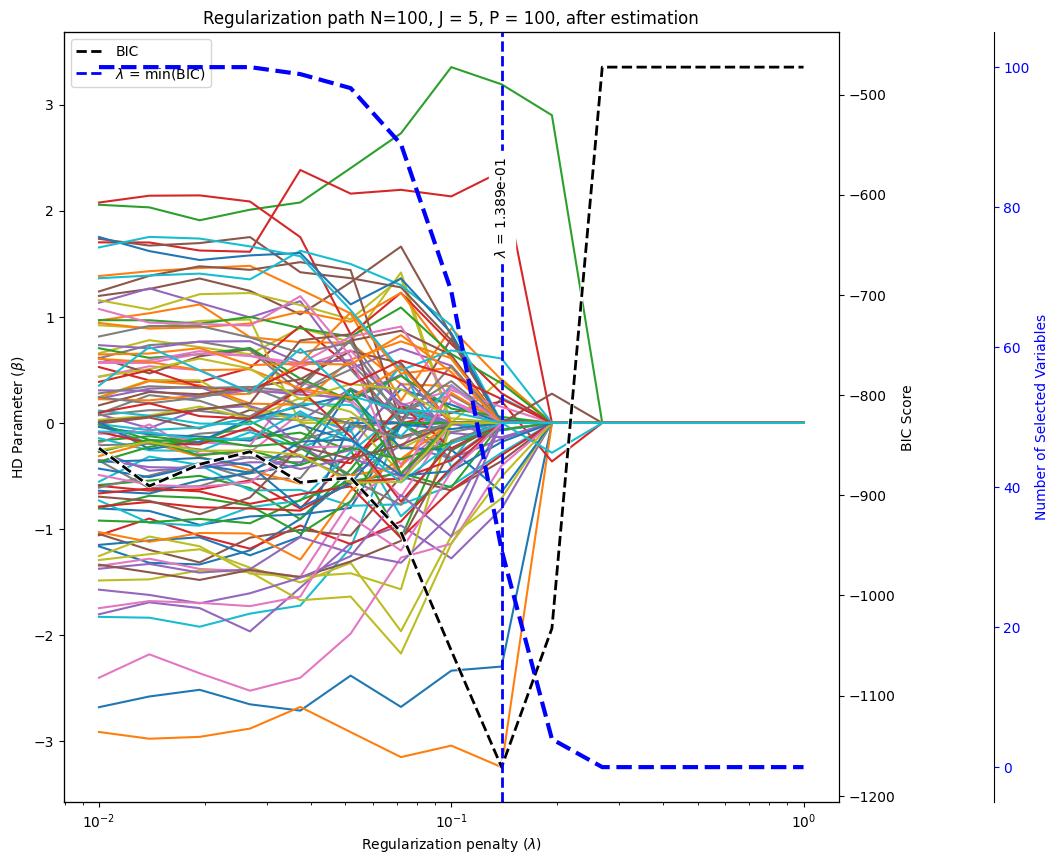

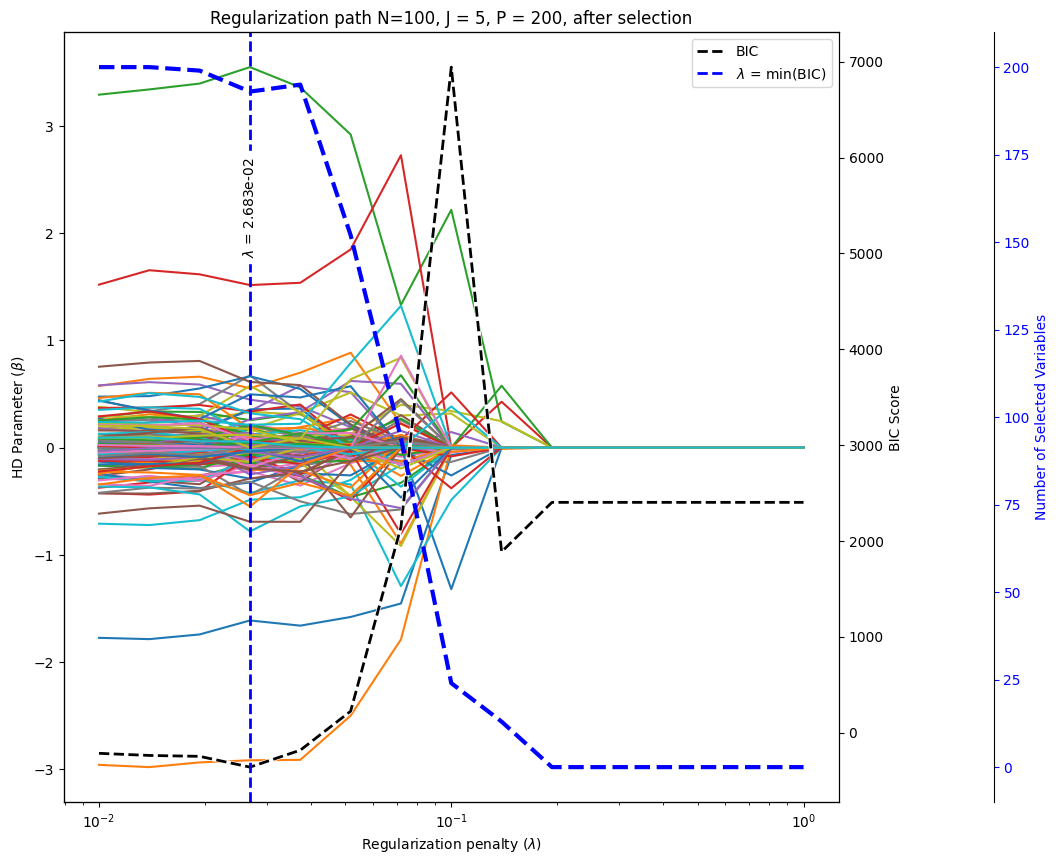

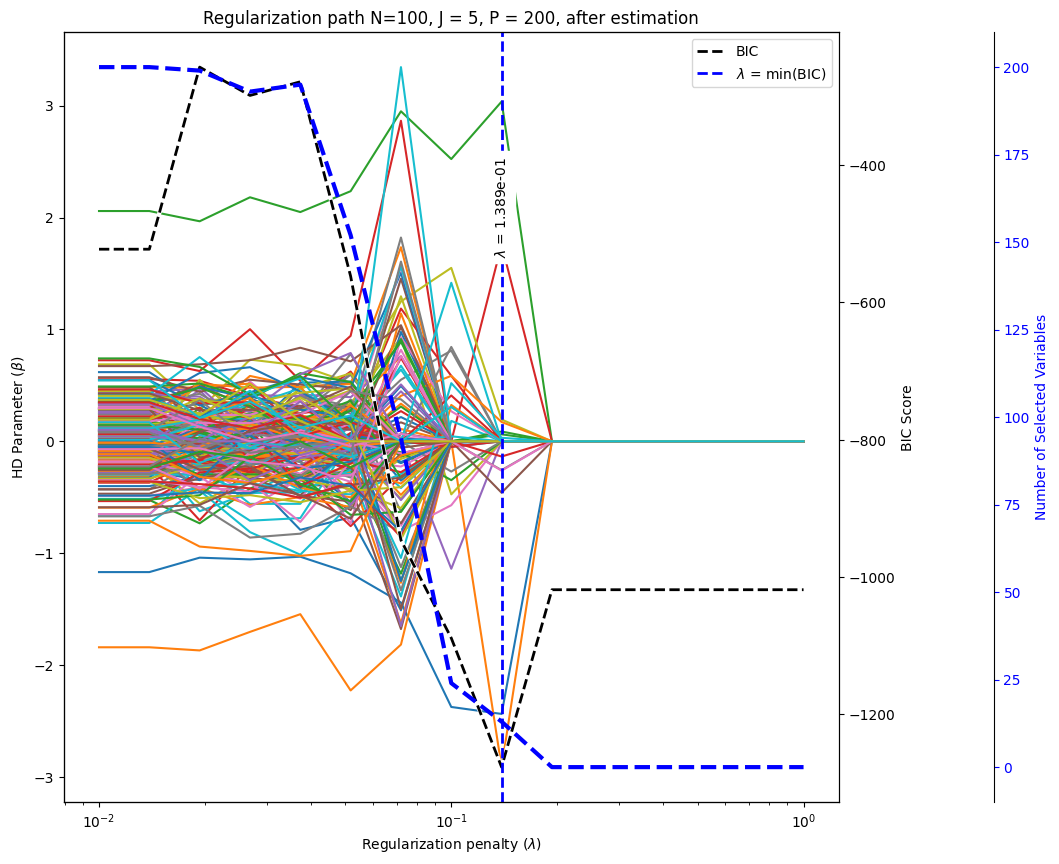

In [17]:
def plot_reg_path(lbd_set, reg_path, bic, DIM_LD):
    multi_theta_HD = [res.theta[-1, DIM_LD:] for res in reg_path]

    fig = sdgplt.figure()
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title("Regularization path")
    ax.set_xlabel(r"Regularization penalty ($\lambda$)")
    ax.set_ylabel(r"HD Parameter ($\beta$)")

    ax.set_xscale("log")

    ax.plot(lbd_set, multi_theta_HD)

    ax_bic = ax.twinx()
    ax_bic.plot(lbd_set, bic, color="w", linewidth=3, linestyle="-")
    ax_bic.plot(lbd_set, bic, color="k", linewidth=2, linestyle="--", label="BIC")
    ax_bic.set(ylabel="BIC Score")
    ax_bic.set(ylabel="BIC Score")

    # minimum value of bic
    idMin = jnp.nanargmin(bic)
    ax_bic = sdgplt.plot_axvline(
        ax_bic, lbd_set, bic, idMin, color="b", msg=" = min(BIC)"
    )

    return fig, [ax, ax_bic]


def plot_reg_paht(bic, reg_path, i):
    fig, axs = plot_reg_path(
        lbd_set, [r[i] for r in reg_path], bic, DIM_LD=model.DIM_LD
    )
    ax, ax_bic = axs
    ax_bic.legend()

    ax_num = ax.twinx()
    ax_num.plot(
        lbd_set,
        [(r[i].theta[-1, 7:] != 0).sum() for r in reg_path],
        color="blue",
        linestyle="--",
        linewidth=3,
    )
    ax_num.spines.right.set_position(("axes", 1.2))
    ax_num.tick_params(axis="y", colors="blue")
    ax_num.set(ylabel="Number of Selected Variables")
    ax_num.yaxis.label.set_color("blue")

    return fig, [ax, ax_bic, ax_num]


fig, ax = plot_reg_paht(bic_selection_100, reg_path_HD_100, 0)
ax[0].set_title(
    f"Regularization path N={model.N}, J = {model.J}, P = {100}, after selection"
)

fig, ax = plot_reg_paht(bic_estimation_100, reg_path_HD_100, 1)
ax[0].set_title(
    f"Regularization path N={model.N}, J = {model.J}, P = {100}, after estimation"
)

# fig, ax = plot_reg_paht(bic_selection_200, reg_path_HD_200, 0)
# ax[0].set_title(
#     f"Regularization path N={model.N}, J = {model.J}, P = {200}, after selection"
# )

# fig, ax = plot_reg_paht(bic_estimation_200, reg_path_HD_200, 1)
# ax[0].set_title(
#     f"Regularization path N={model.N}, J = {model.J}, P = {200}, after estimation"
# )